In [2]:
from cProfile import label

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sympy import rotations

In [3]:
data = pd.read_excel('combined.xlsx')
data

,Дата,Станция,Име,Номер на карта,Име на артикул,Литри,Тип количество,GTA цена,Сума по GTA цена,ЕКО цена,Сума по ЕКО цена,Час,Километри,company
0,2026-01-26,1106 Пловдив В. Априлов,АУ10,78970151027720192,DIESEL EKONOMY,48.039,L15,NaN,NaN,1.28,61.49,18:52:00,0.0,Аграрен Университет Пловдив
1,2026-01-05,1130 Пловдив Кукленско шосе,АУ3,78970151027720112,DIESEL EKONOMY,27.559,L15,NaN,NaN,1.27,35.00,08:04:00,0.0,Аграрен Университет Пловдив
2,2026-01-13,1907 О5 Пловдив,АУ4,78970151027720128,DIESEL EKONOMY,70.008,L15,NaN,NaN,1.26,88.21,13:08:00,0.0,Аграрен Университет Пловдив
3,2026-01-19,1907 О5 Пловдив,АУ6,78970151027720144,DIESEL EKONOMY,55.810,L15,NaN,NaN,1.26,70.32,09:19:00,0.0,Аграрен Университет Пловдив
4,2026-01-20,1907 О5 Пловдив,АУ10,78970151027720192,DIESEL EKONOMY,41.381,L15,NaN,NaN,1.26,52.14,16:05:00,0.0,Аграрен Университет Пловдив
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1356,2026-02-13,"1903 София, О5 Царско село",B9325TM,78970156027720256,95 EKONOMY UNLEADED,31.858,L15,NaN,NaN,1.27,40.46,10:11:00,0.0,Хранинвест % Търговци
1357,2026-02-18,"1903 София, О5 Царско село",B9325TM,78970156027720256,95 EKONOMY UNLEADED,35.000,L15,NaN,NaN,1.27,44.45,10:55:00,0.0,Хранинвест % Търговци
1358,2026-02-26,1162 София Люлин П. Владигеров,B9325TM,78970156027720256,95 EKONOMY UNLEADED,29.587,L15,NaN,NaN,1.26,37.28,10:07:00,0.0,Хранинвест % Търговци
1359,2026-02-13,1148 Варна пристанище,2,78970153027720208,95 EKONOMY UNLEADED,32.000,L15,NaN,NaN,1.25,40.00,12:25:00,0.0,Unknown


In [4]:
data['company'].value_counts()

company
Меркурий производство и Пакетаж    199
Фуудс трейд                        196
Хранинвест % Продажби              164
Спедстрой ООД                      129
ДЖИ ТИ ЕЙ ПЕТРОЛИУМ                 90
Поди ЕООД                           54
Скимпрот % група 2                  45
Димитров Експрес Карго              35
ЕВРОУЕЙ СЪРВИЗ ООД                  34
Желязков инженеринг ЕООД            34
Скимпрот % група 1                  32
Диляна – 02 ЕООД                    24
Живко Неделчев Димитров ЕГН 760     24
Мултиарт ЕООД                       21
Аграрен Университет Пловдив         21
БКС Долни Чифлик                    19
Док транс ЕООД                      18
Хранинвест % Доставки               18
Община Добричка                     17
Диянис ЕООД                         16
Земеделска техника ООД              16
Демакс АД % Група 1                 15
Делор 20 ЕООД                       14
Пантекс Агро ЕООД                   12
Комерс Нови Пазар ЕООД              11
Адига ЕООД       

In [5]:
data['Име на артикул'].value_counts()

Име на артикул
DIESEL EKONOMY                              887
95 EKONOMY UNLEADED                         216
DIESEL DOUBLE FILTERED                       75
Е GAS LPG                                    56
EKO RACING 100                               55
4 L. WINTER SCREENWASH - READY FOR USAGE     16
2L WINTER SCREEN WASH LIQUID                 13
ADBLUE 1L                                     9
10L ADPLUS DIESEL ADDITIVE                    3
5L SONAX WINTER SCREENWASH - READY            3
5L NIGRIN WINTER SCREENWASH -18C              3
5Л. ДОБАВКА ADBLUE ДИЗЕЛОВИ ДВИГАТЕЛИ         2
4 L. WINTER SCREENWASH - CONCENTRATЕ          2
1L MEGATRON ULTRA 10W-40 LUBS                 2
1 L. WINTER SCREENWASH CONCENTRATE            2
0.5L. WATER BANKIA                            1
AIR-FRESHENER AREON DRY DOUBLE BUBBLE         1
LITTLE JOE - STANDART - FRESH MINT            1
2L SUMMER SCREEN WASH LIQUID                  1
AIR-FRESHENER AREON MON XXL                   1
BLIST.2825 5W 12V W2,1X9,

In [6]:
de_hraninvest_prodajbi = data[(data['company'] == 'Хранинвест % Продажби') & (data['Име на артикул'] == 'DIESEL EKONOMY')]

benzin95_hraninvest_prodajbi = data[(data['company'] == 'Хранинвест % Продажби') & (data['Име на артикул'] == '95 EKONOMY UNLEADED')]

ddf_hraninvest_prodajbi = data[(data['company'] == 'Хранинвест % Продажби') & (data['Име на артикул'] == 'DIESEL DOUBLE FILTERED')]

benzin100_hraninvest_prodajbi = data[(data['company'] == 'Хранинвест % Продажби') & (data['Име на артикул'] == 'EKO RACING 100')]

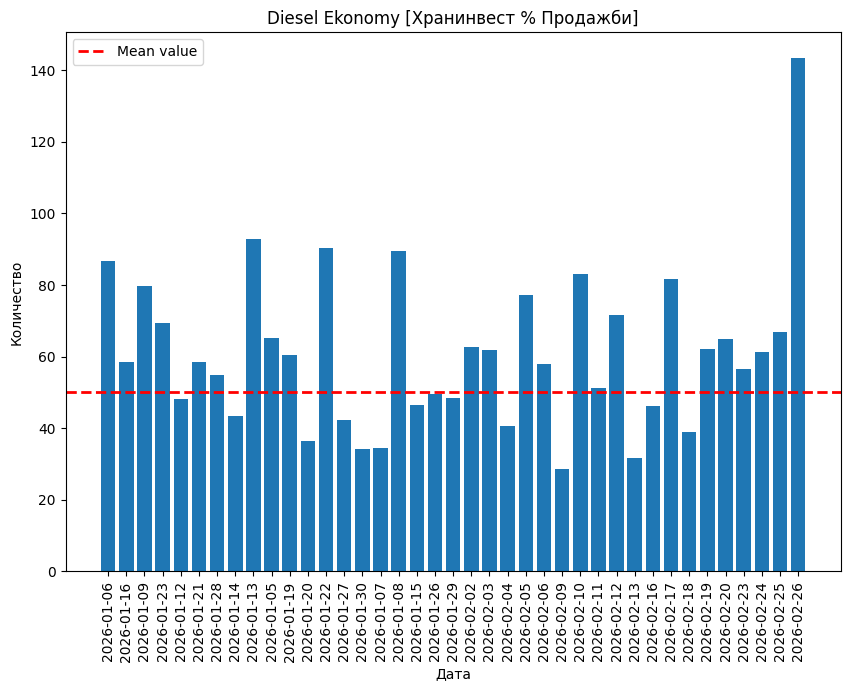

In [7]:
plt.figure(figsize=(10, 7))

mean_value = de_hraninvest_prodajbi['Литри'].mean()

plt.bar(de_hraninvest_prodajbi['Дата'], de_hraninvest_prodajbi['Литри'])
plt.axhline(mean_value, color='red', linestyle='--', linewidth=2, label='Mean value')
plt.title('Diesel Ekonomy [Хранинвест % Продажби]')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()

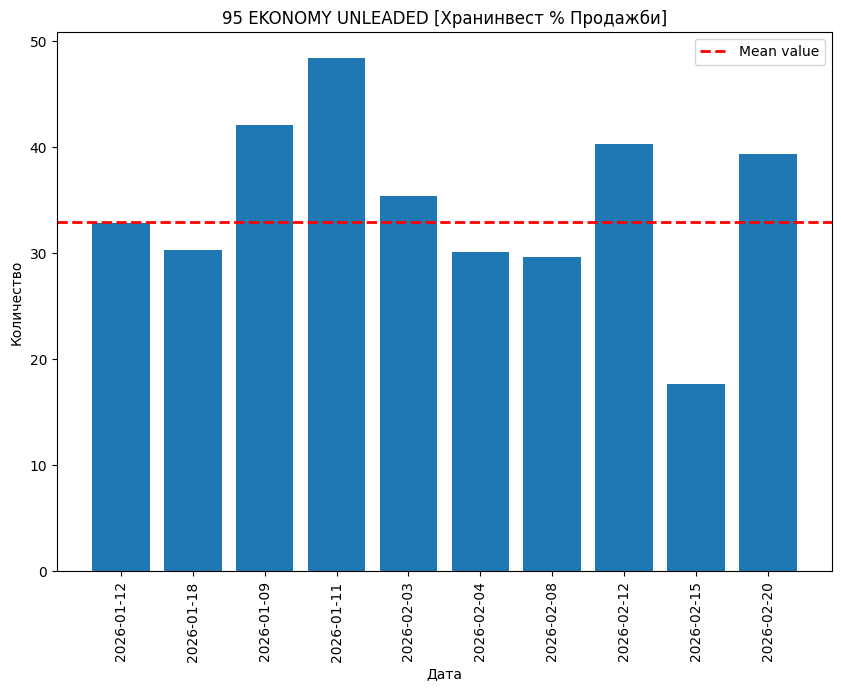

In [8]:
plt.figure(figsize=(10, 7))

mean_value = benzin95_hraninvest_prodajbi['Литри'].mean()

plt.bar(benzin95_hraninvest_prodajbi['Дата'], benzin95_hraninvest_prodajbi['Литри'])
plt.axhline(mean_value, color='red', linestyle='--', linewidth=2, label='Mean value')
plt.title('95 EKONOMY UNLEADED [Хранинвест % Продажби]')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()

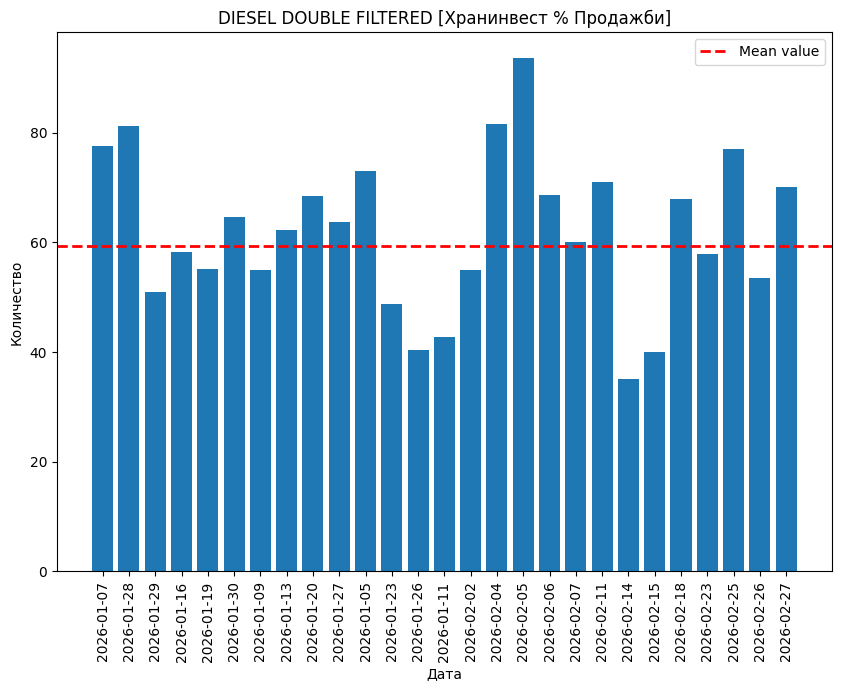

In [9]:
plt.figure(figsize=(10, 7))

mean_value = ddf_hraninvest_prodajbi['Литри'].mean()

plt.bar(ddf_hraninvest_prodajbi['Дата'], ddf_hraninvest_prodajbi['Литри'])
plt.axhline(mean_value, color='red', linestyle='--', linewidth=2, label='Mean value')
plt.title('DIESEL DOUBLE FILTERED [Хранинвест % Продажби]')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()

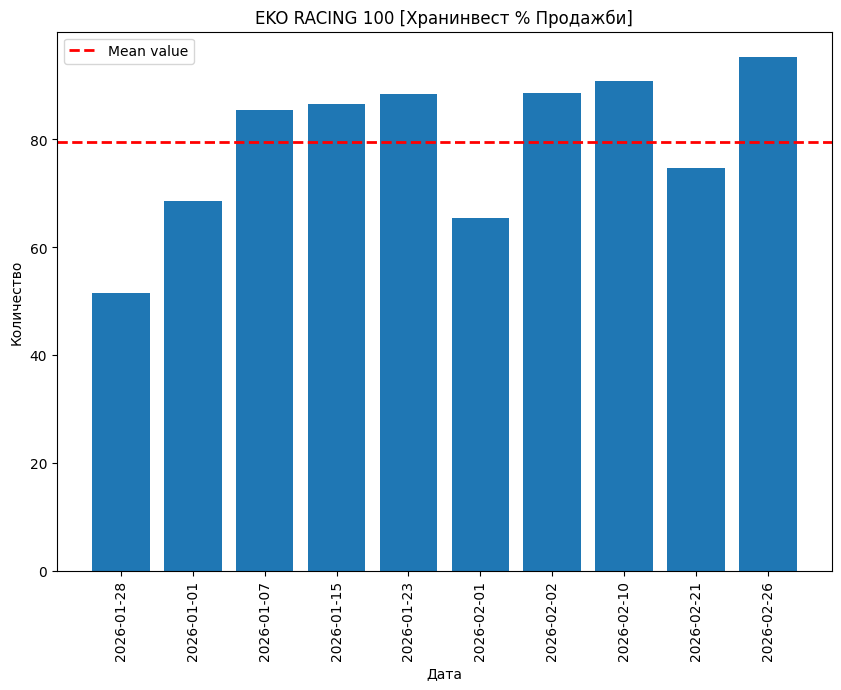

In [10]:
plt.figure(figsize=(10, 7))

mean_value = benzin100_hraninvest_prodajbi['Литри'].mean()

plt.bar(benzin100_hraninvest_prodajbi['Дата'], benzin100_hraninvest_prodajbi['Литри'])
plt.axhline(mean_value, color='red', linestyle='--', linewidth=2, label='Mean value')
plt.title('EKO RACING 100 [Хранинвест % Продажби]')
plt.legend()
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.xticks(rotation=90)
plt.show()